# Task 2.1: Dataset Selection and Setup

**Paper**: Weisfeiler-Lehman Graph Kernels (Shervashidze et al., JMLR 2011)

**Student**: Meghavi (Roll: 230044)

## Dataset Description

We generate a **synthetic labeled graph classification dataset** with two classes:

| Property | Value |
|----------|-------|
| Total graphs | 200 (100 per class) |
| Node count range | 6 to 15 |
| Node label alphabet | {0, 1, 2} |
| Random seed | 42 |

- **Class 0 ("Tree-like")**: Random trees generated via `nx.random_labeled_tree()`. Node labels biased toward label 0 with probability distribution [0.5, 0.3, 0.2].
- **Class 1 ("Cyclic")**: Graphs with a cycle core and tree branches. Node labels biased toward label 1 with probability distribution [0.2, 0.5, 0.3].

### Justification

This mimics the paper's molecular graph classification setting (e.g., MUTAG tests mutagenicity of molecular compounds). Tree-like vs. cyclic structures represent fundamentally different graph topologies that the WL kernel should distinguish through iterative neighborhood label aggregation.

### Limitations vs. Paper's Datasets

- Fewer nodes per graph (6–15 vs. 17–39 in MUTAG)
- Fewer label types (3 vs. 7 atom types in MUTAG)
- No real chemical meaning
- Clearer class separation than real molecular data

In [1]:
import numpy as np
import networkx as nx
import pickle
import os

SEED = 42
np.random.seed(SEED)
N_PER_CLASS = 100
NODE_RANGE = (6, 15)
LABEL_SET = [0, 1, 2]

## Generate Class 0: Tree-like Graphs

Random trees are acyclic connected graphs. We use `nx.random_labeled_tree()` and assign node labels with a distribution biased toward label 0.

In [2]:
def generate_tree_graphs(n_graphs, node_range, label_probs, rng):
    """Generate random tree graphs (Class 0)."""
    graphs = []
    for i in range(n_graphs):
        n_nodes = rng.integers(node_range[0], node_range[1] + 1)
        G = nx.random_labeled_tree(n=n_nodes, seed=int(rng.integers(0, 2**31)))
        labels = {v: int(rng.choice(LABEL_SET, p=label_probs)) for v in G.nodes()}
        nx.set_node_attributes(G, labels, 'label')
        graphs.append(G)
    return graphs

rng = np.random.default_rng(SEED)
class0_graphs = generate_tree_graphs(N_PER_CLASS, NODE_RANGE, [0.5, 0.3, 0.2], rng)
print(f"Class 0: {len(class0_graphs)} tree graphs generated")
print(f"  Example: {class0_graphs[0].number_of_nodes()} nodes, {class0_graphs[0].number_of_edges()} edges")

Class 0: 100 tree graphs generated
  Example: 6 nodes, 5 edges


## Generate Class 1: Cyclic Graphs

These graphs have a cycle core with tree branches attached. We start with `nx.cycle_graph()` and attach remaining nodes randomly.

In [3]:
def generate_cyclic_graphs(n_graphs, node_range, label_probs, rng):
    """Generate cyclic graphs with a cycle core + tree branches (Class 1)."""
    graphs = []
    for i in range(n_graphs):
        n_nodes = rng.integers(node_range[0], node_range[1] + 1)
        # Create cycle core (at least 3 nodes, up to n_nodes)
        cycle_size = rng.integers(3, min(n_nodes, max(4, n_nodes // 2)) + 1)
        G = nx.cycle_graph(cycle_size)
        # Attach remaining nodes as branches
        for v in range(cycle_size, n_nodes):
            parent = int(rng.integers(0, v))
            G.add_edge(parent, v)
        labels = {v: int(rng.choice(LABEL_SET, p=label_probs)) for v in G.nodes()}
        nx.set_node_attributes(G, labels, 'label')
        graphs.append(G)
    return graphs

class1_graphs = generate_cyclic_graphs(N_PER_CLASS, NODE_RANGE, [0.2, 0.5, 0.3], rng)
print(f"Class 1: {len(class1_graphs)} cyclic graphs generated")
print(f"  Example: {class1_graphs[0].number_of_nodes()} nodes, {class1_graphs[0].number_of_edges()} edges")

Class 1: 100 cyclic graphs generated
  Example: 8 nodes, 8 edges


## Combine and Save Dataset

In [4]:
# Combine graphs and labels
all_graphs = class0_graphs + class1_graphs
all_labels = np.array([0] * N_PER_CLASS + [1] * N_PER_CLASS)

# Convert to adjacency list + node label format for storage
dataset = {
    'graphs': [],
    'labels': all_labels
}

for G in all_graphs:
    adj_list = list(G.edges())
    node_labels = {v: G.nodes[v]['label'] for v in G.nodes()}
    dataset['graphs'].append({
        'adj_list': adj_list,
        'node_labels': node_labels,
        'n_nodes': G.number_of_nodes(),
        'n_edges': G.number_of_edges()
    })

# Save to file
data_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'partB', 'data')
os.makedirs(data_dir, exist_ok=True)
save_path = os.path.join(data_dir, 'synthetic_dataset.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(dataset, f)

print(f"Dataset saved to {save_path}")
print(f"Total graphs: {len(all_graphs)}")
print(f"Class distribution: {np.bincount(all_labels)}")

Dataset saved to /Users/zebra/230044-midsem/partB/data/synthetic_dataset.pkl
Total graphs: 200
Class distribution: [100 100]


## Dataset Statistics

In [5]:
# Print dataset statistics
print("Dataset Statistics:")
print("=" * 50)
for cls, graphs in [(0, class0_graphs), (1, class1_graphs)]:
    n_nodes_list = [G.number_of_nodes() for G in graphs]
    n_edges_list = [G.number_of_edges() for G in graphs]
    print(f"\nClass {cls} ({'Tree-like' if cls == 0 else 'Cyclic'}):")
    print(f"  Graphs: {len(graphs)}")
    print(f"  Nodes: min={min(n_nodes_list)}, max={max(n_nodes_list)}, mean={np.mean(n_nodes_list):.1f}")
    print(f"  Edges: min={min(n_edges_list)}, max={max(n_edges_list)}, mean={np.mean(n_edges_list):.1f}")
    # Check for cycles
    has_cycle = [not nx.is_tree(G) for G in graphs]
    print(f"  Contains cycle: {sum(has_cycle)}/{len(graphs)}")

Dataset Statistics:

Class 0 (Tree-like):
  Graphs: 100
  Nodes: min=6, max=15, mean=10.6
  Edges: min=5, max=14, mean=9.6
  Contains cycle: 0/100

Class 1 (Cyclic):
  Graphs: 100
  Nodes: min=6, max=15, mean=10.2
  Edges: min=6, max=15, mean=10.2
  Contains cycle: 100/100


## Visualize Example Graphs

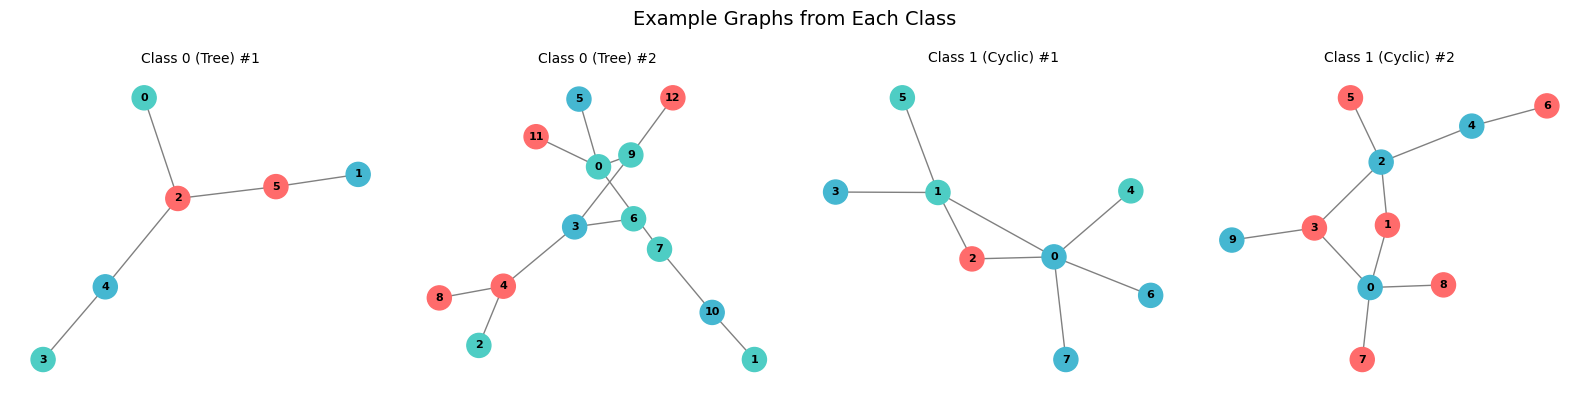

Plot saved to partB/results/dataset_examples.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
color_map = {0: '#4ECDC4', 1: '#FF6B6B', 2: '#45B7D1'}

for idx, (ax, G, title) in enumerate(zip(
    axes,
    [class0_graphs[0], class0_graphs[1], class1_graphs[0], class1_graphs[1]],
    ['Class 0 (Tree) #1', 'Class 0 (Tree) #2', 'Class 1 (Cyclic) #1', 'Class 1 (Cyclic) #2']
)):
    pos = nx.spring_layout(G, seed=42)
    node_colors = [color_map[G.nodes[v]['label']] for v in G.nodes()]
    nx.draw(G, pos, ax=ax, node_color=node_colors, with_labels=True,
            node_size=300, font_size=8, font_weight='bold', edge_color='gray')
    ax.set_title(title, fontsize=10)

plt.suptitle('Example Graphs from Each Class', fontsize=14)
plt.tight_layout()
results_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'partB', 'results')
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, 'dataset_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to partB/results/dataset_examples.png")